In [9]:
# 1. Install the tool and the license wrapper
!pip install "autorom[accept-rom-license]"

# 2. Run the command-line tool to download the ROMs
!AutoROM --accept-license

!apt-get install -y swig python3-dev

%pip install cmake --quiet
%pip install multi_agent_ale_py --quiet
%pip install "pettingzoo[atari]" AutoROM --quiet



AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms
	/usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_

In [13]:
import sys, subprocess
import matplotlib.pyplot as plt
from pettingzoo.atari import pong_v3
from IPython import display
subprocess.run([sys.executable, "-m", "AutoROM", "--accept-license"], check=False)

CompletedProcess(args=['/usr/bin/python3', '-m', 'AutoROM', '--accept-license'], returncode=1)

In [28]:
def get_pos_refined(obs, color):
    # Snij het scherm bij: verwijder de bovenste 34 pixels (score)
    # en de onderste 16 pixels (rand).
    # We kijken ook niet naar de uiterste zijkanten (0-15 en 144-160).
    play_area = obs[34:184, 15:145]

    # Zoek de pixels
    indices = np.where(np.all(play_area == color, axis=-1))

    if len(indices[0]) > 0:
        # Tel de 34 pixels die we hebben afgesneden er weer bij op
        # voor de juiste absolute Y-positie
        return np.mean(indices[0]) + 34
    return None

# Exacte RGB waarden voor Atari Pong
BALL_COLOR = [236, 236, 236]
PADDLE_COLOR_1 = [92, 186, 92]
PADDLE_COLOR_2 = [213, 130, 74]

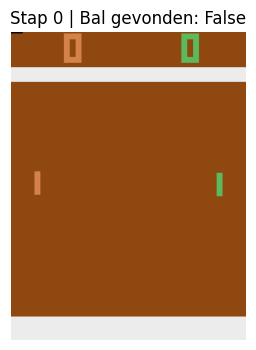

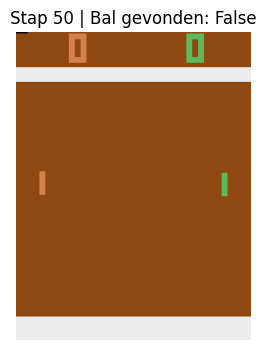

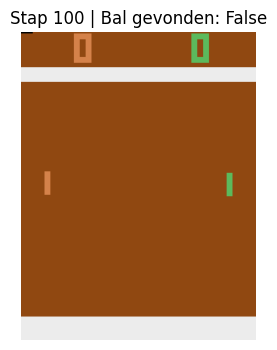

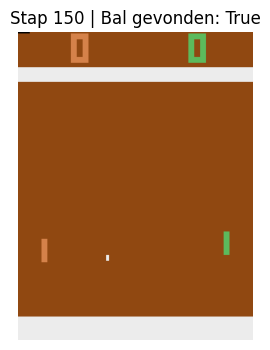

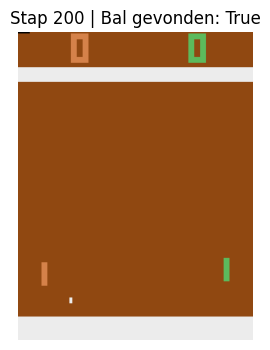

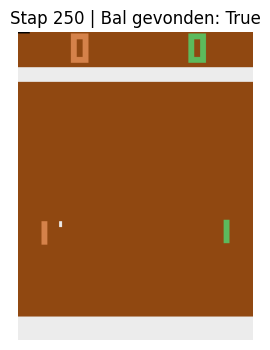

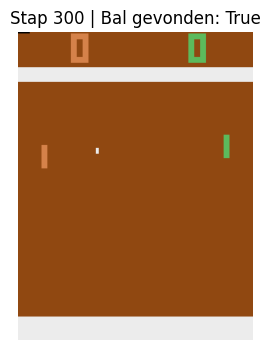

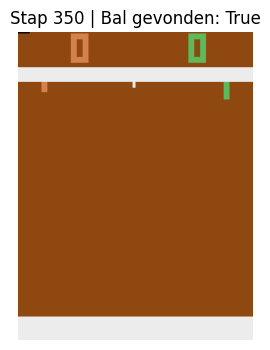

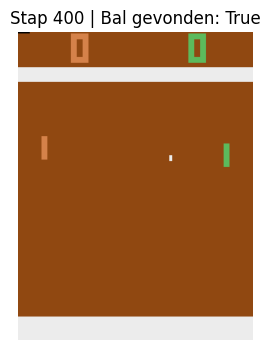

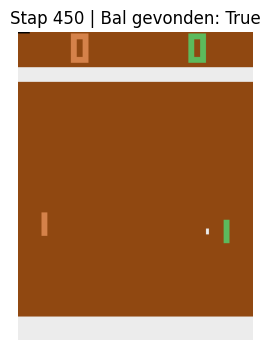

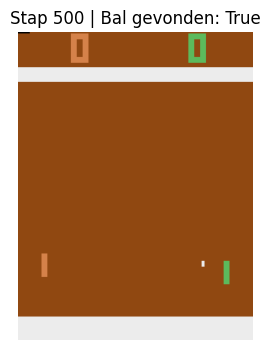

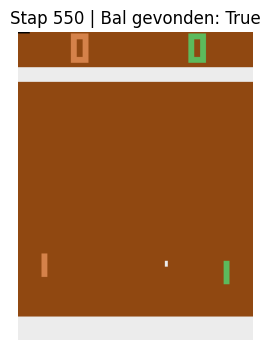

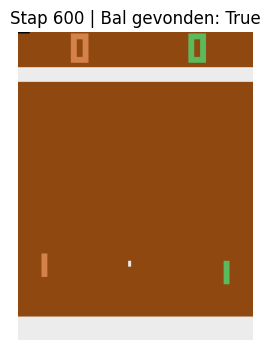

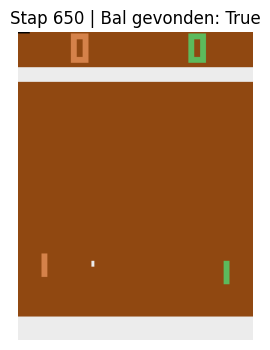

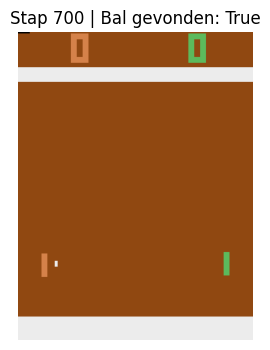

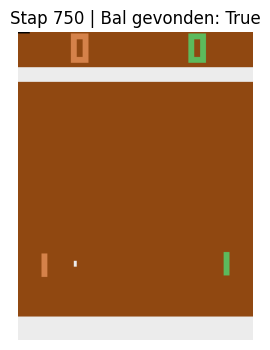

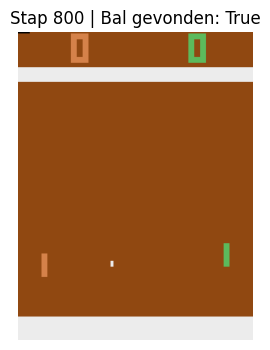

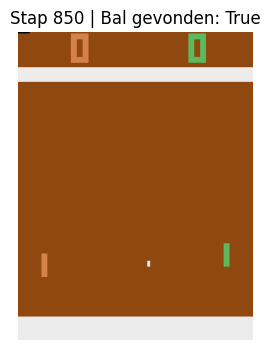

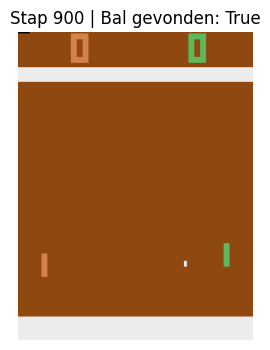

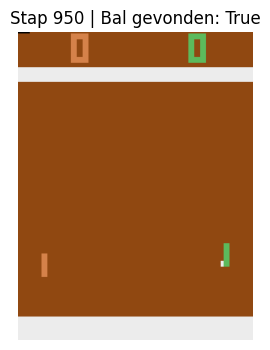

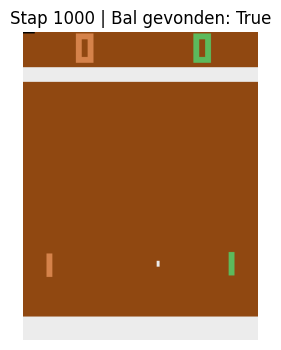

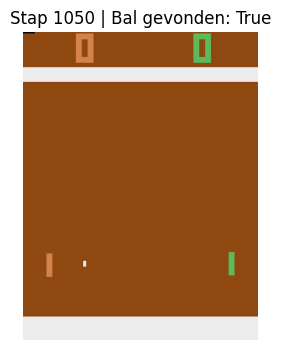

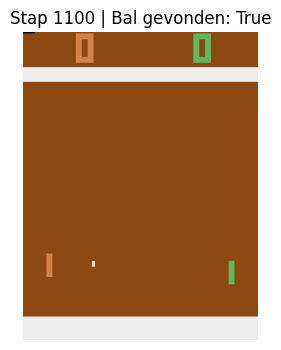

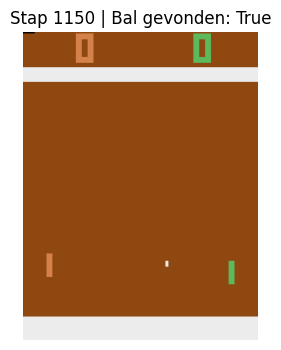

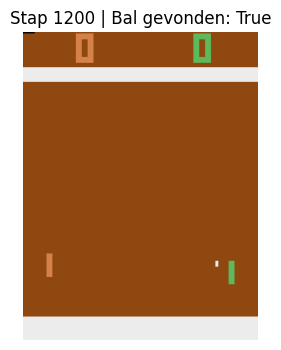

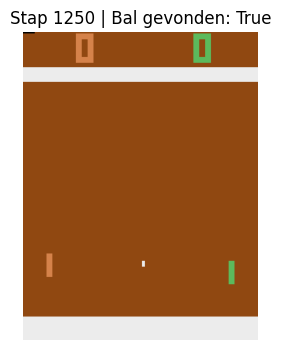

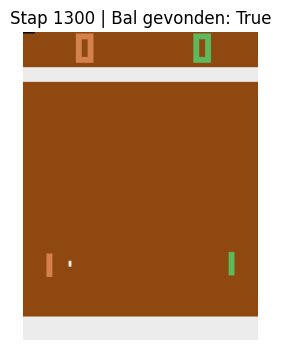

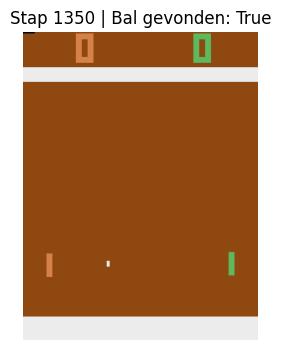

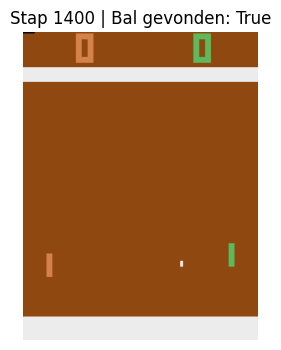

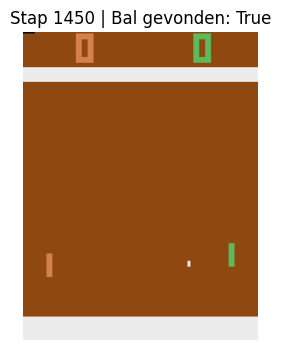

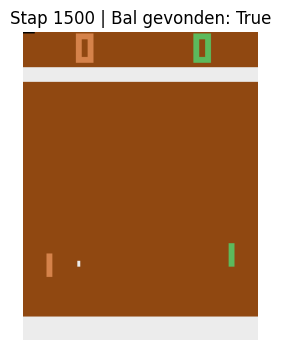

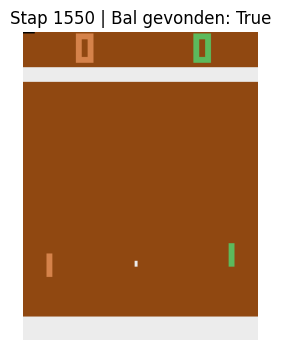

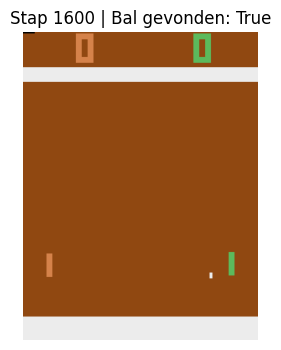

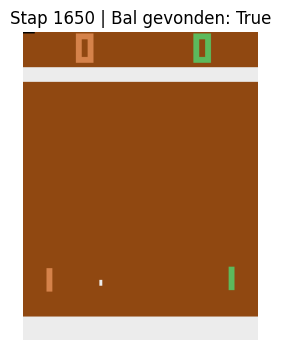

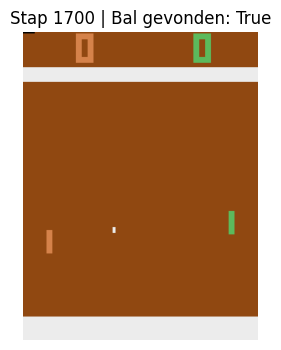

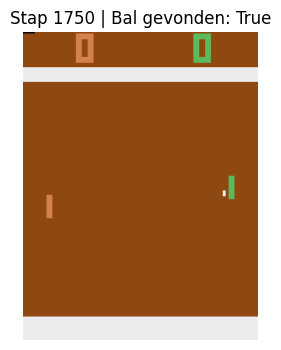

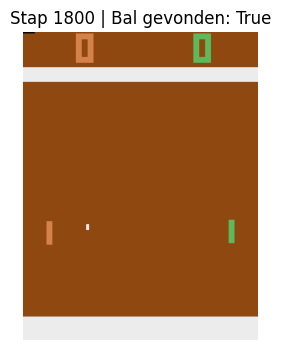

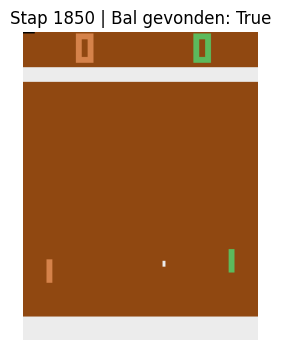

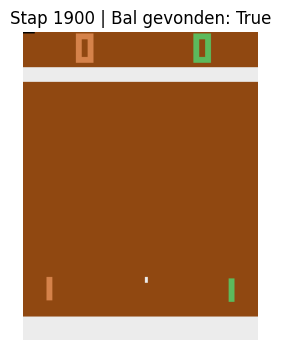

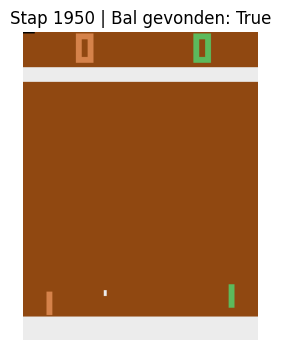

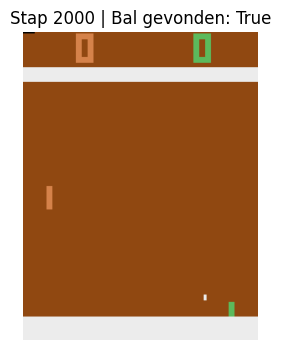

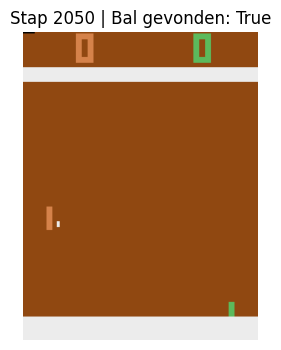

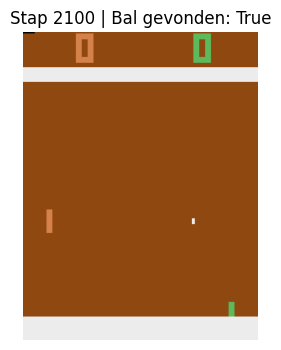

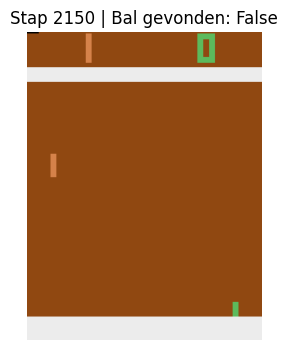

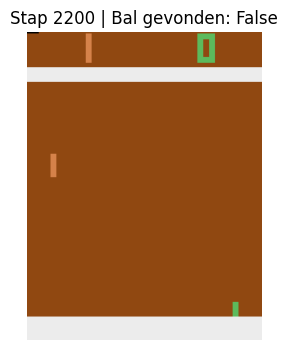

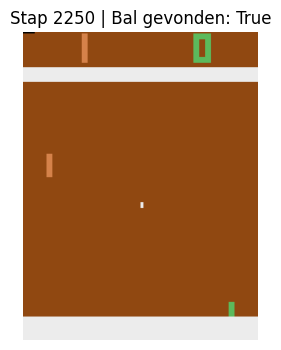

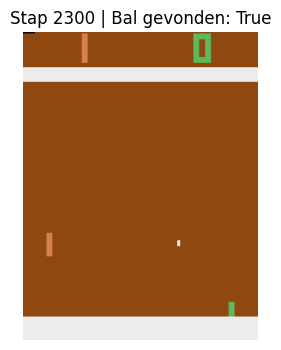

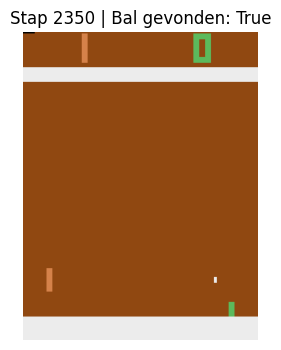

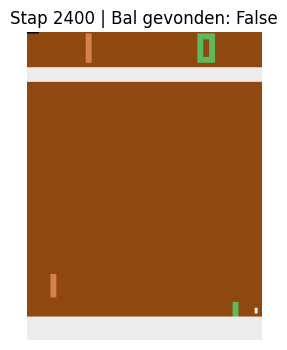

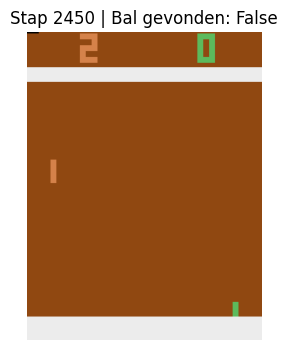

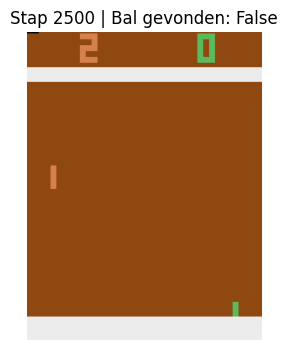

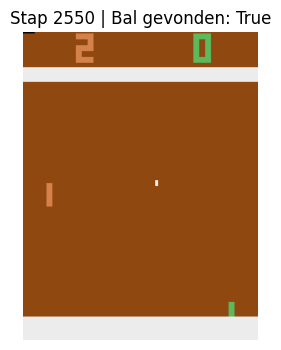

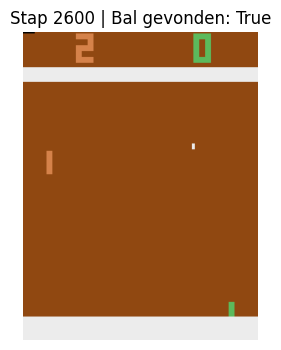

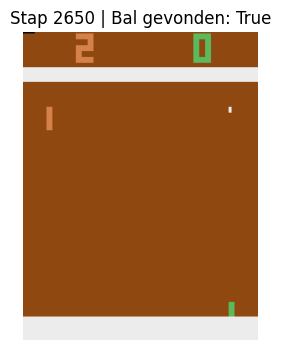

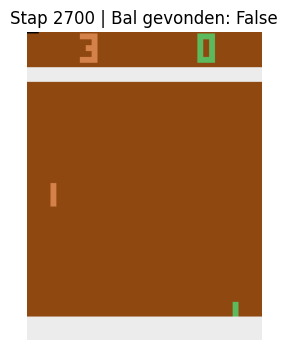

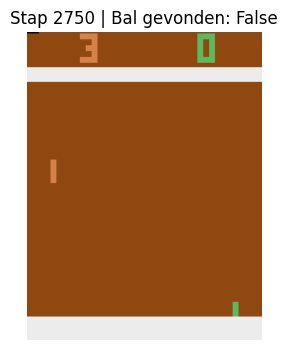

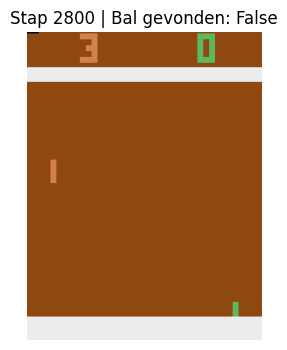

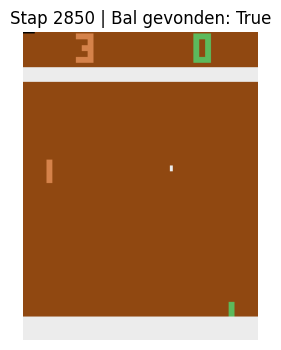

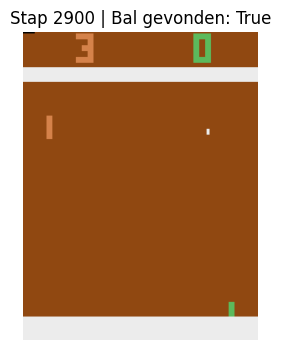

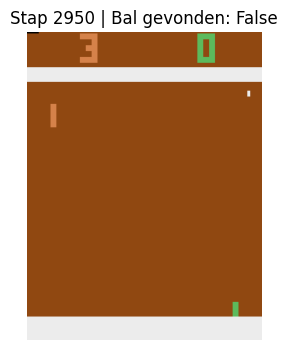

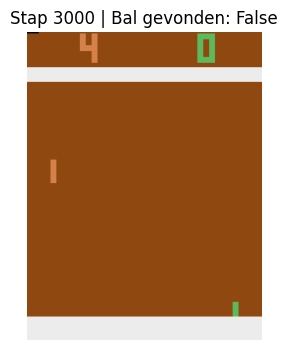

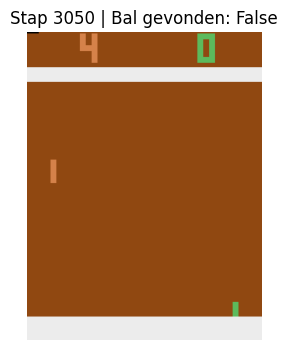

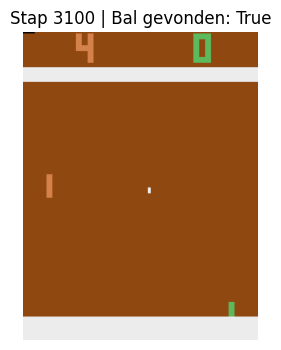

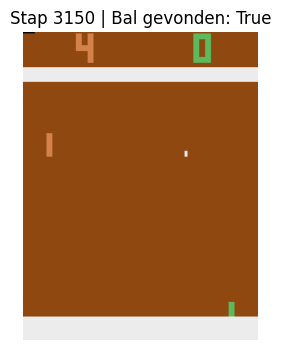

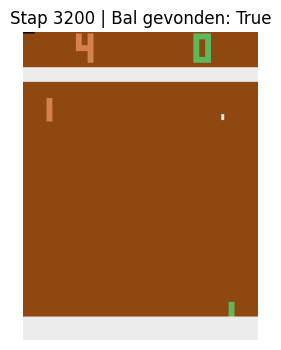

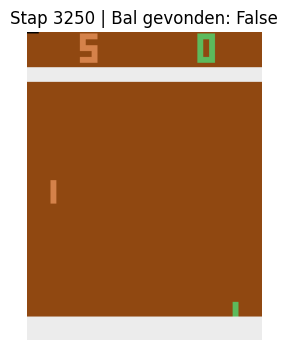

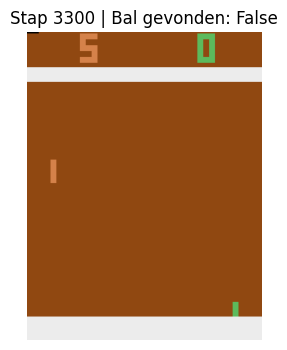

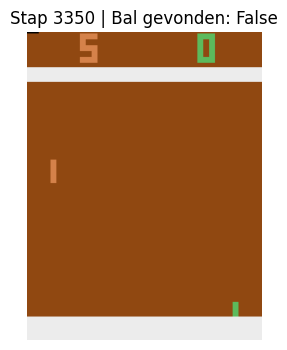

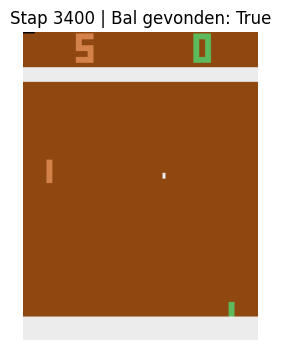

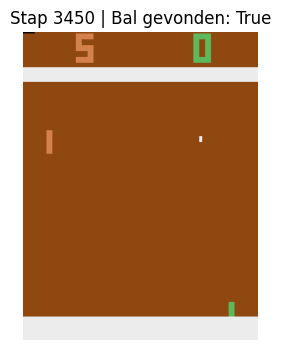

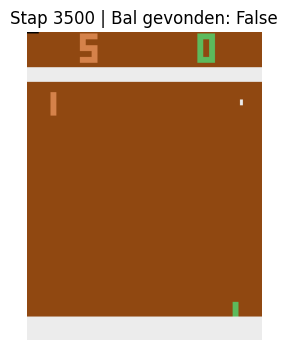

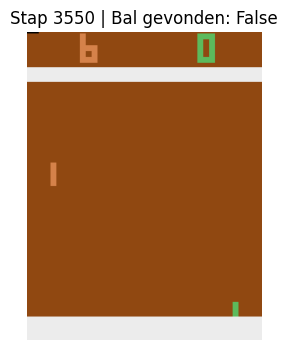

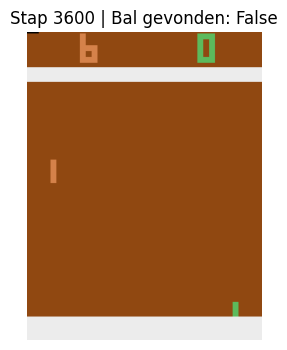

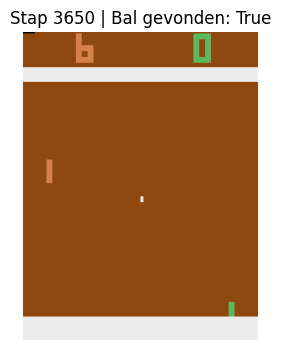

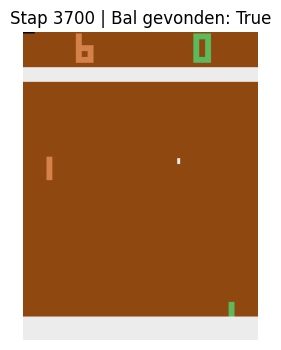

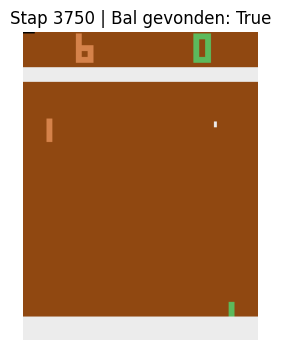

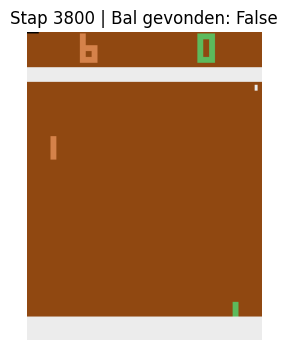

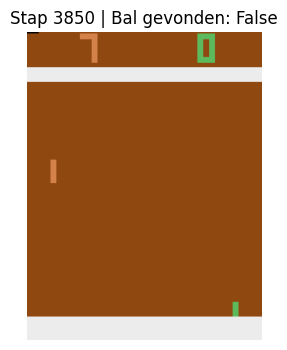

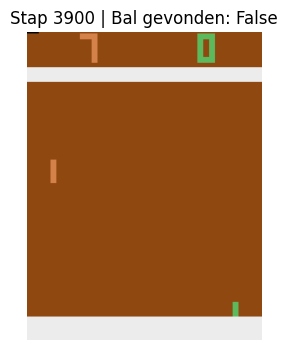

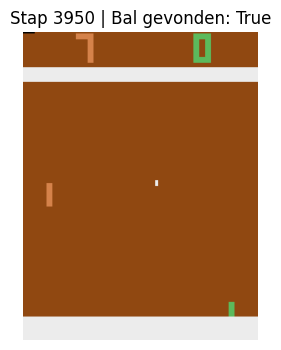

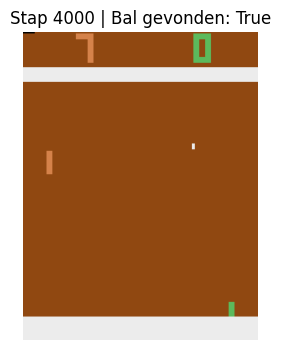

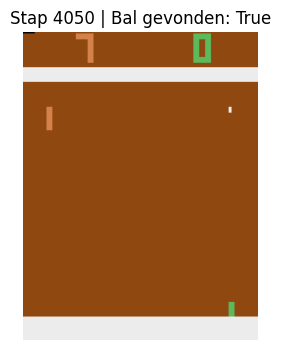

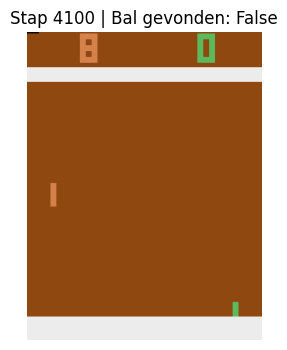

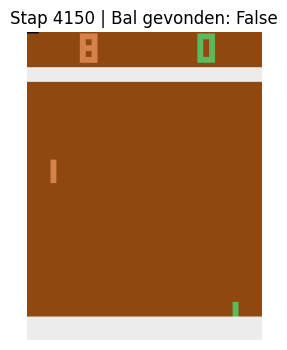

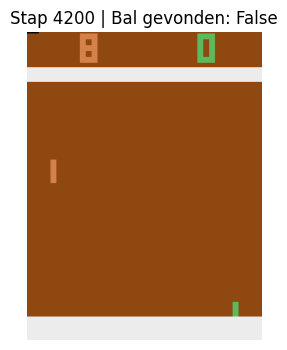

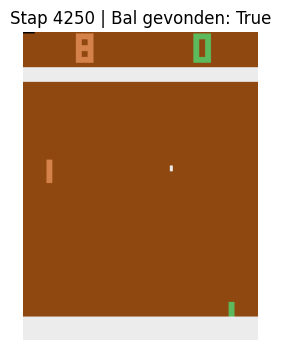

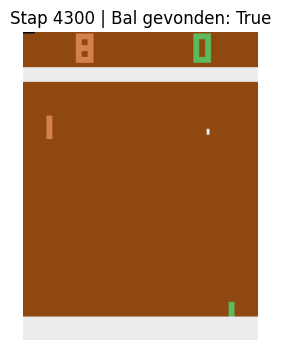

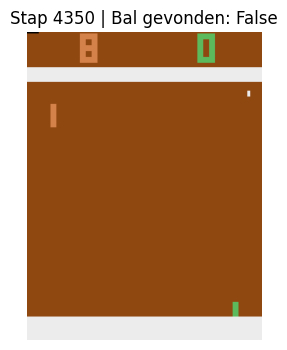

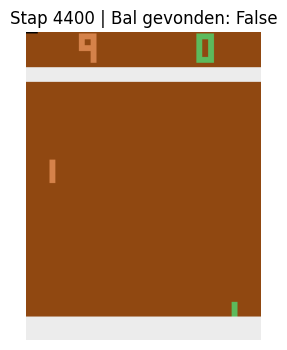

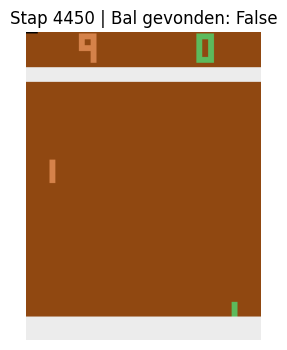

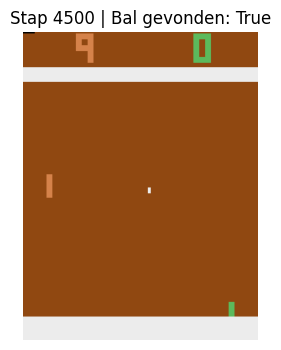

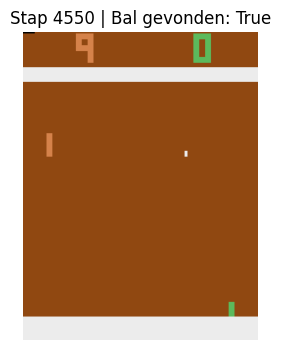

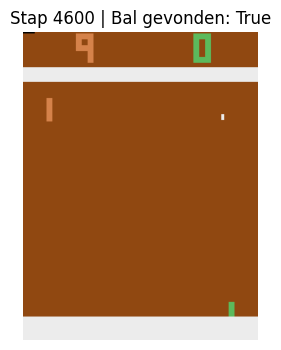

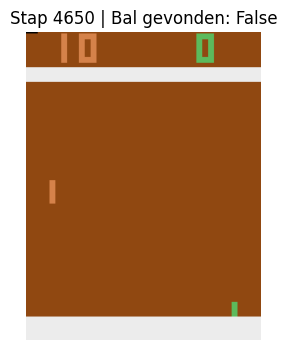

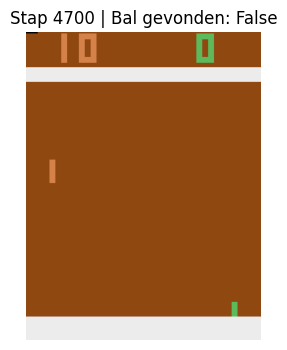

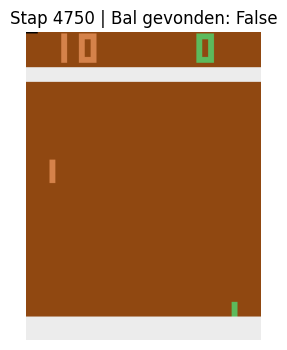

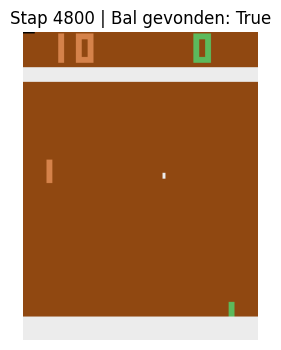

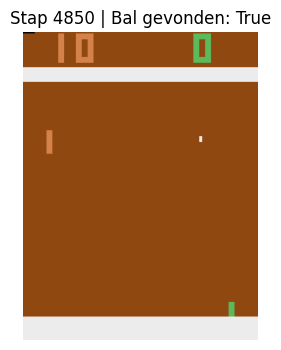

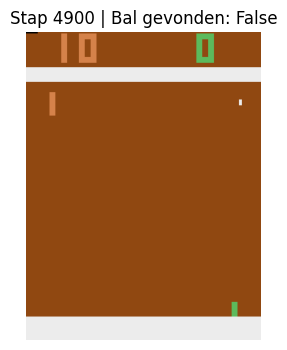

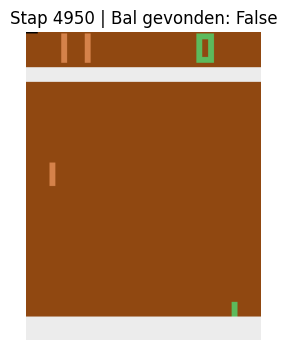

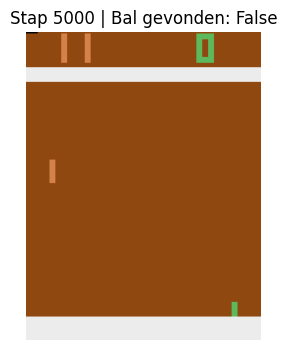

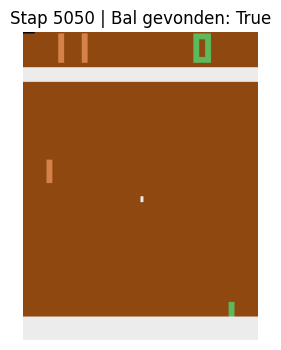

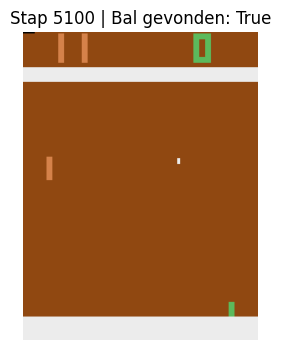

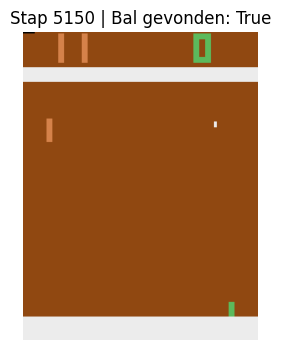

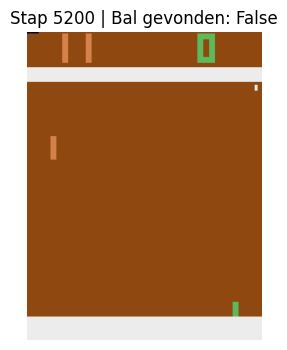

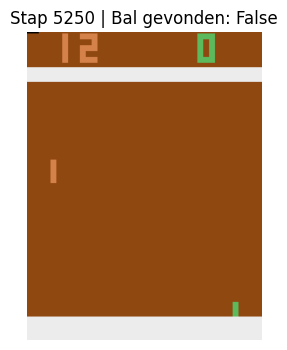

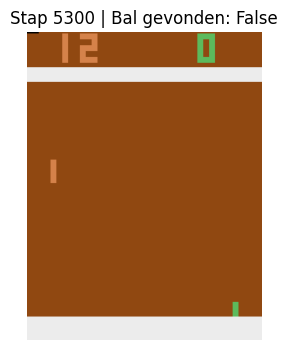

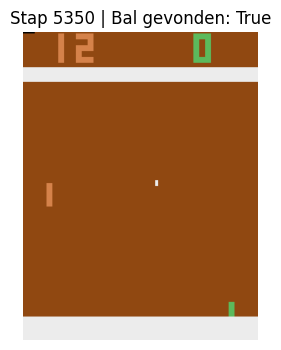

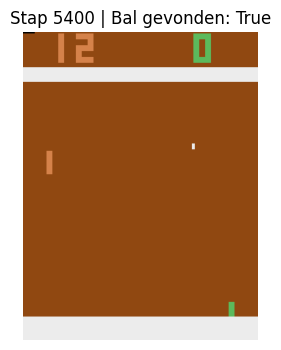

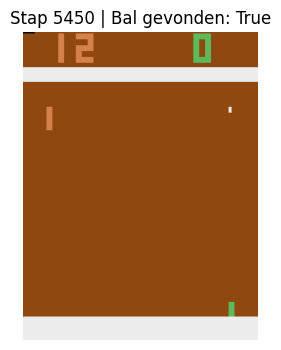

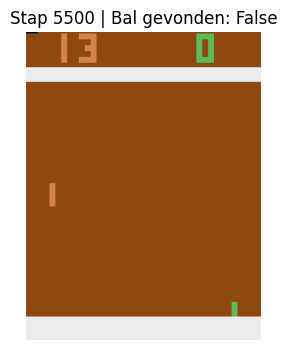

KeyboardInterrupt: 

In [30]:
env = pong_v3.env(render_mode="rgb_array")
env.reset(seed=42)

max_steps = 10000
step = 0

for agent in env.agent_iter():
    observation, reward, termination, truncation, info = env.last()

    if termination or truncation:
        action = None
    else:
        # 1. Posities bepalen
        ball_y = get_pos_refined(observation, BALL_COLOR)
        my_color = PADDLE_COLOR_1 if agent == "first_0" else PADDLE_COLOR_2
        my_y = get_pos_refined(observation, my_color)

        # 2. Beslissen wat we doen
        if ball_y is not None and my_y is not None:
            # Volg de bal: als bal_y lager is dan my_y (dus kleiner getal), ga omhoog
            if ball_y < (my_y - 3):
                action = 2  # Omhoog
            elif ball_y > (my_y + 3):
                action = 3  # Omlaag
            else:
                action = 0  # Blijf staan (bal is op gelijke hoogte)
        else:
            # DIT IS HET BELANGRIJKSTE:
            # Als de bal nog niet gespawned is, druk op FIRE (1)
            # en beweeg vast naar het midden (bijv. y=100)
            if my_y is not None and my_y > 110:
                action = 2 # Ga vast omhoog richting midden
            elif my_y is not None and my_y < 90:
                action = 3 # Ga vast omlaag richting midden
            else:
                action = 1 # FIRE! (Lanceren van de bal)

    env.step(action)

    # Renderen: doe dit niet elke stap (stap % 1), maar bijv. elke 50 stappen
    if step % 50 == 0:
        frame = env.render()
        plt.figure(figsize=(6, 4))
        plt.imshow(frame)
        plt.axis("off")
        plt.title(f"Stap {step} | Bal gevonden: {ball_y is not None}")
        plt.show()

    step += 1
    if step >= max_steps:
        break

env.close()
print("Pong klaar!")